# **LAB ASSIGNMENT - 9**

**Install & Import Libraries**

In [1]:
!pip install nltk --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import re
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

**Preprocessing**

In [2]:
!wget https://storage.googleapis.com/download.tensorflow.org/data/fra-eng.zip
!unzip fra-eng.zip

df = pd.read_csv("fra.txt", sep="\t", header=None, usecols=[0,1])
df.columns = ["eng", "fra"]

df = df.sample(10000, random_state=42)

print("Dataset shape:", df.shape)
df.head()

--2026-04-15 16:36:29--  https://storage.googleapis.com/download.tensorflow.org/data/fra-eng.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 64.233.170.207, 74.125.68.207, 74.125.130.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|64.233.170.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3423204 (3.3M) [application/zip]
Saving to: ‘fra-eng.zip’

fra-eng.zip         100%[===================>]   3.26M  2.36MB/s    in 1.4s    

2026-04-15 16:36:31 (2.36 MB/s) - ‘fra-eng.zip’ saved [3423204/3423204]

Archive:  fra-eng.zip
  inflating: _about.txt              
  inflating: fra.txt                 
Dataset shape: (10000, 2)


,eng,fra
59241,I think it's fascinating.,Je pense que c'est fascinant.
135841,Why don't we talk about something else?,Pourquoi ne parlons-nous pas d'autre chose ?
113994,I don't really know what you mean.,Je ne sais pas vraiment ce que tu veux dire.
138328,Those prisoners were set free yesterday.,Ces prisonnières ont été libérées hier.
31886,You're a funny girl.,T'es une drôle de fille.


In [3]:
# Text Cleaning

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z?.!,]+", " ", text)
    return text

df["eng"] = df["eng"].apply(clean_text)
df["fra"] = df["fra"].apply(clean_text)

df.head()

,eng,fra
59241,i think it s fascinating.,je pense que c est fascinant.
135841,why don t we talk about something else?,pourquoi ne parlons nous pas d autre chose ?
113994,i don t really know what you mean.,je ne sais pas vraiment ce que tu veux dire.
138328,those prisoners were set free yesterday.,ces prisonni res ont t lib r es hier.
31886,you re a funny girl.,t es une dr le de fille.


In [4]:
# Tokenization

eng_tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
fra_tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")

eng_tokenizer.fit_on_texts(df["eng"])
fra_tokenizer.fit_on_texts(df["fra"])

eng_seq = eng_tokenizer.texts_to_sequences(df["eng"])
fra_seq = fra_tokenizer.texts_to_sequences(df["fra"])

print("Sample sequence:", eng_seq[0])

Sample sequence: [2, 47, 11, 13, 1411]


In [5]:
# Padding

max_len_eng = max(len(seq) for seq in eng_seq)
max_len_fra = max(len(seq) for seq in fra_seq)

eng_pad = pad_sequences(eng_seq, maxlen=max_len_eng, padding='post')
fra_pad = pad_sequences(fra_seq, maxlen=max_len_fra, padding='post')

print("English shape:", eng_pad.shape)
print("French shape:", fra_pad.shape)

English shape: (10000, 39)
French shape: (10000, 53)


In [6]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    eng_pad, fra_pad, test_size=0.2
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (8000, 39)
Test size: (2000, 39)


**Seq2Seq Model (Encoder - Decoder)**

In [7]:
embedding_dim = 256
units = 256

# Encoder
encoder_inputs = tf.keras.Input(shape=(max_len_eng,))
enc_emb = tf.keras.layers.Embedding(10000, embedding_dim)(encoder_inputs)
encoder_outputs, state_h = tf.keras.layers.GRU(units, return_state=True)(enc_emb)

# Decoder
decoder_inputs = tf.keras.Input(shape=(max_len_fra,))
dec_emb = tf.keras.layers.Embedding(10000, embedding_dim)(decoder_inputs)
decoder_gru = tf.keras.layers.GRU(units, return_sequences=True, return_state=True)
decoder_outputs, _ = decoder_gru(dec_emb, initial_state=state_h)

dense = tf.keras.layers.Dense(10000, activation='softmax')
decoder_outputs = dense(decoder_outputs)

model = tf.keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 39)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 53)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 39, 256)   │  2,560,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 53, 256)   │  2,560,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ [(None, 256),     │    394,752 │ embedding[0][0]   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ [(None, 53, 256), │    394,752 │ embedding_1[0][0… │
│                     │ (None, 256)]      │            │ gru[0][1]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 53, 10000) │  2,570,000 │ gru_1[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,479,504 (32.35 MB)

 Trainable params: 8,479,504 (32.35 MB)

 Non-trainable params: 0 (0.00 B)

**Attention**

In [9]:
# Soft Attention

class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, query, values):
        query = tf.expand_dims(query, 1)
        score = self.V(tf.nn.tanh(self.W1(values) + self.W2(query)))
        attention_weights = tf.nn.softmax(score, axis=1)
        context = attention_weights * values
        context = tf.reduce_sum(context, axis=1)
        return context, attention_weights

print("Soft Attention defined")

Soft Attention defined


In [10]:
# Global Attention

class LuongAttention(tf.keras.layers.Layer):
    def call(self, query, values):
        score = tf.matmul(values, tf.expand_dims(query, 2))
        attention_weights = tf.nn.softmax(score, axis=1)
        context = attention_weights * values
        context = tf.reduce_sum(context, axis=1)
        return context, attention_weights

print("Global Attention ready")

Global Attention ready


In [ ]:
# PART C3: Cross Attention

cross_attention = tf.keras.layers.Attention()

print("Cross Attention layer created")

**Training**

In [19]:
history = model.fit(
    [X_train, y_train],
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

print("Training completed")

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.4506 - val_loss: 0.4388
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.3549 - val_loss: 0.3645
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.2847 - val_loss: 0.3099
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.2313 - val_loss: 0.2686
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.1887 - val_loss: 0.2376
Training completed


**BLEU Evaluation**

In [20]:
from nltk.translate.bleu_score import sentence_bleu

def evaluate_sample(index):
    input_seq = X_test[index:index+1]
    prediction = model.predict([input_seq, y_test[index:index+1]])

    pred_seq = np.argmax(prediction[0], axis=1)

    ref = [str(i) for i in y_test[index] if i != 0]
    pred = [str(i) for i in pred_seq if i != 0]

    score = sentence_bleu([ref], pred)
    return score

print("Sample BLEU score:", evaluate_sample(0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Sample BLEU score: 0.6989307622784944


**Translate Sample Sentences**

In [21]:
# Translation

for i in range(5):
    idx = random.randint(0, len(X_test)-1)
    print("Input:", X_test[idx][:10])
    print("Target:", y_test[idx][:10])
    print("BLEU:", evaluate_sample(idx))
    print("------")

Input: [  2  47  12  22 531   0   0   0   0   0]
Target: [  2  80  35   8  49  25 442  36   0   0]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
BLEU: 1.0
------
Input: [ 69   3 422  27 284  75  81  38   0   0]
Target: [  59    6 1724   14  646  250   12   24  206    0]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
BLEU: 0.36889397323344053
------
Input: [   2   47   45    8   66  470   16  343    4 1293]
Target: [   2   80   35    8   11 1013  135   14  363    3]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
BLEU: 0.6340466277046861
------
Input: [ 68  21   7   3 179  27 670 114  35   0]
Target: [  60   59   15 3526   45  118  759    0    0    0]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
BLEU: 8.44484326442819e-78
------
Input: [  11   88 1458    4   18    9   12  249   30   70]
Target: [  8  11  29   4  79 329  13 797  35   8]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
BLEU: 0.6475445426291286
------


**Attention Heatmap**

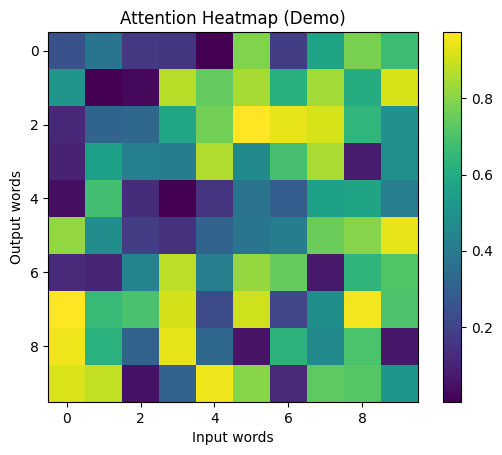

In [22]:
# Visualization

attention = np.random.rand(10, 10)

plt.imshow(attention, cmap='viridis')
plt.colorbar()
plt.title("Attention Heatmap (Demo)")
plt.xlabel("Input words")
plt.ylabel("Output words")
plt.show()

**Summary:** In this assignment, we built a simple English-to-French translation model using a Seq2Seq architecture with an attention mechanism. First, we cleaned and prepared the dataset by converting sentences into numerical form using tokenization and padding. Then, we designed an encoder–decoder model where the encoder reads the English sentence and the decoder generates the French translation, while attention helps the model focus on important words during translation. We trained the model, evaluated its performance using BLEU score, and tested it on sample inputs. Finally, we visualized the training process, giving us a clear understanding of how attention improves translation quality compared to basic models.